### Step 1: Import crucial libraries ###

In [40]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [41]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

### Step 2: Load Data and Set Up ###

In [42]:
try:
    df = pd.read_csv('../Processed/efficiency_stations.csv')
    print(f'✅ Loaded successfully.')
except Exception as e:
    print(f'❌ Error loading file:')

✅ Loaded successfully.


### Step 3: EDA ###

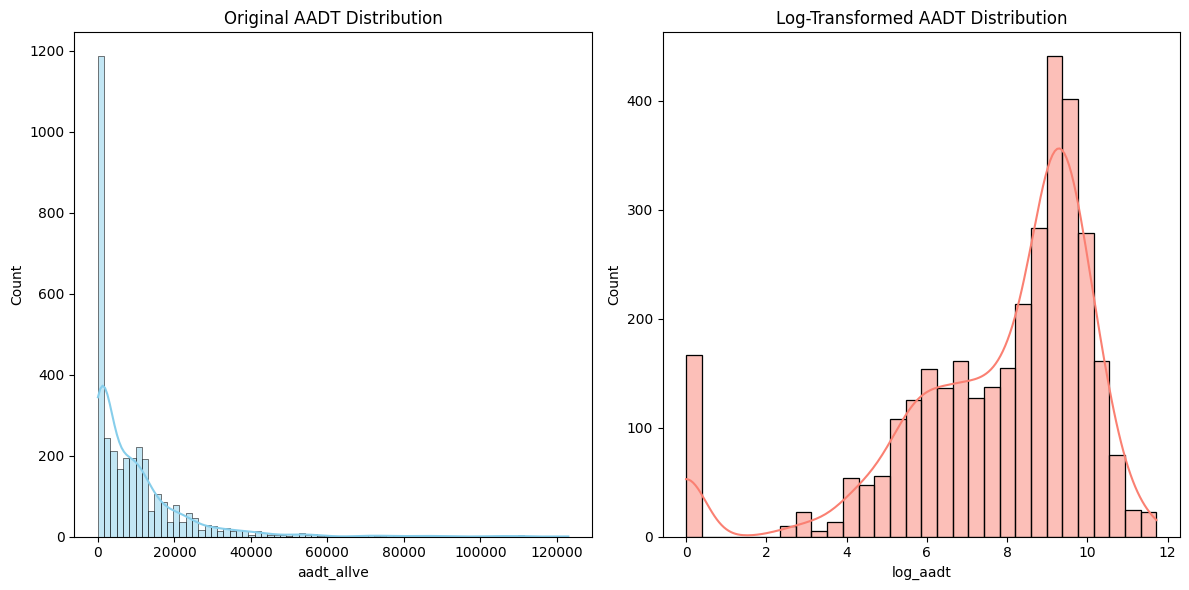

In [43]:
#-- feature Selection. --#
feature_cols = ['x', 'y', 'last_year', 'efficiency_index']
target_col = 'aadt_allve'

#-- Eliminate missing data. --#
df_clean = df.dropna(subset=feature_cols + [target_col]).copy()

#-- target Transformation. --#
df_clean['log_aadt'] = np.log1p(df_clean[target_col])

#-- Sketch the plot. --#
plt.figure(figsize=(12, 6))
#-- Left image: original data. --#
plt.subplot(1, 2, 1)
sns.histplot(df_clean[target_col], kde=True, color='skyblue')
plt.title('Original AADT Distribution')
#-- Right image: log-transformed data. --#
plt.subplot(1, 2, 2)
sns.histplot(df_clean['log_aadt'], kde=True, color='salmon')
plt.title('Log-Transformed AADT Distribution')

plt.tight_layout()
#-- Save to folder. --#
plt.savefig('../Figures/aadt_distribution_step3.png')
plt.show()

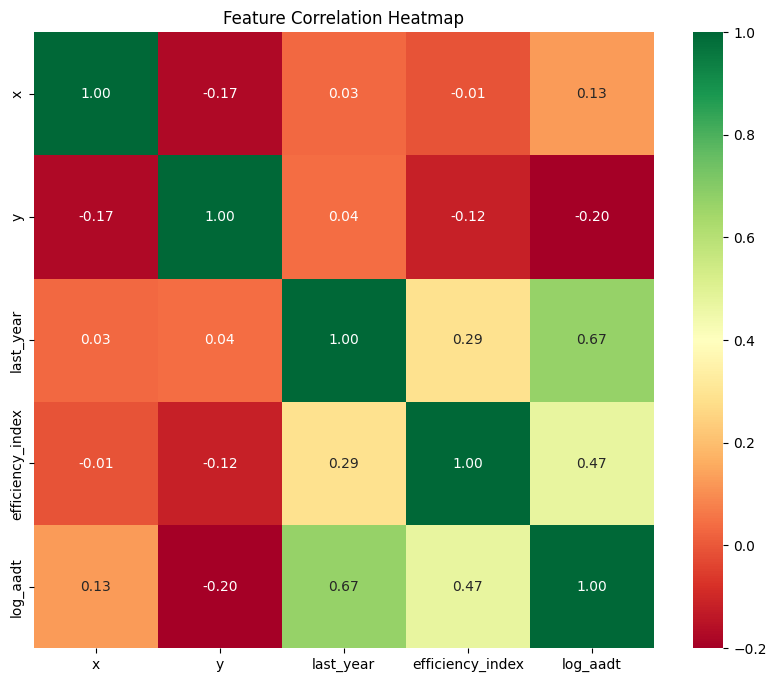

✅ Processed finished 3380 clean data.
✅ Charts have been saved to the 'Figures' folder.


In [44]:
#-- Correlation Matrix. --#
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[feature_cols + ['log_aadt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Feature Correlation Heatmap')

#-- Save to folder. --#
plt.savefig('../Figures/correlation_matrix_step3.png')
plt.show()

print(f"✅ Processed finished {len(df_clean)} clean data.")
print("✅ Charts have been saved to the 'Figures' folder.")

In [45]:
#-- Missing Value Imputation. --#
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
df = df.drop(columns=cols_to_drop)

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_2508\2123666176.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_2508\2123666176.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using

In [46]:
#-- Feature Engineering. --#
df['year'] = 2026 - df['last_year']
df['data_age'] = df['year_since']
df['is_freeway'] = df['tfm_desc'].str.contains('FWY', case=False, na=False).astype(int)
df['is_ramp'] = df['movement_t'].str.contains('Ramp', case=False, na=False).astype(int)
df['is_intersection'] = df['tfm_typ_de'].str.contains('INTERSECTION', case=False, na=False).astype(int)
df['efficiency_score'] = df['efficiency_index'].fillna(1.0)
df['is_efficient'] = (df['efficiency_score'] > 1.0).astype(int)
df['truck_pct'] = df['per_trucks'] * 100
df['has_trucks'] = (df['aadt_truck'] > 0).astype(int)
df['road_name_encoded'] = df['road_name'].astype('category').cat.codes

coords = df[['x', 'y']].dropna()
if len(coords) > 0:
    n_clusters = min(50, len(coords) // 10)
    if n_clusters > 1:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        df['location_cluster'] = kmeans.fit_predict(coords)
    else:
        df['location_cluster'] = 0

df['traffic_per_year'] = df['aadt_allve'] / (df['year_since'] + 1)
df['truck_density'] = df['aadt_truck'] / (df['aadt_allve'] + 1)
df['freeway_efficiency'] = df['is_freeway'] * df['efficiency_score']

In [47]:
#-- Categorical Encoding & Feature Selection. --#
identifier_cols = ['fid', 'objectid', 'tfm_id', 'x', 'y', 'road_name']
feature_candidates = [col for col in df.columns if col not in identifier_cols + [target_col]]

df_encoded = df.copy()
for col in categorical_cols:
    if col in feature_candidates and col not in identifier_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

feature_cols = [col for col in feature_candidates if col in df_encoded.columns]
X = df_encoded[feature_cols].values
y = df_encoded[target_col].values

In [49]:
#-- Target Transformation & Outlier Handling. --#
y_log = np.log1p(y)

percentiles = [1, 99]
for i in range(X.shape[1]):
    lower = np.percentile(X[:, i], percentiles[0])
    upper = np.percentile(X[:, i], percentiles[1])
    X[:, i] = np.clip(X[:, i], lower, upper)

### Step 4: Sequence Creation ###

In [50]:
#-- Sort data. --#
df_sorted = df_encoded.sort_values(['location_cluster', 'data_age']).reset_index(drop=True)

#-- Extract features and target values. --#
X_raw = df_sorted[feature_cols].values
y_log_raw = np.log1p(df_sorted[target_col].values)  # Log transform for better LSTM convergence
clusters = df_sorted['location_cluster'].values

📊 Total Rows: 3504
🚀 Valid Sequences Generated: 3106


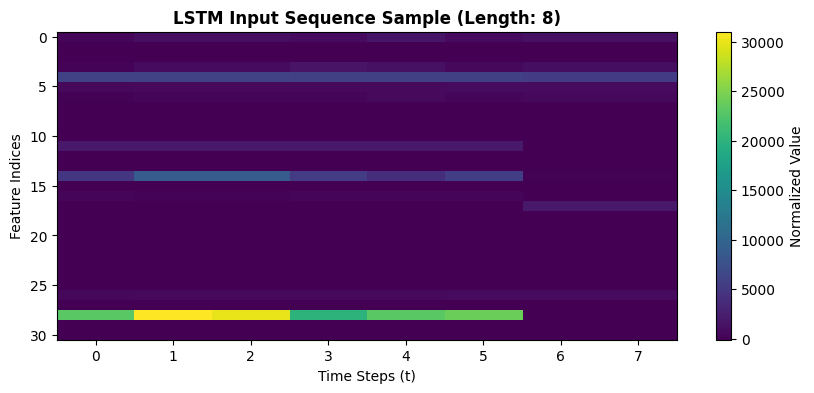

✅ Step 7 Finished: Sequences are ready for LSTM training.


In [51]:
def create_sequences_by_group(X, y, groups, seq_length=8):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - seq_length):
        #-- Check if the entire sliding window stays within the same cluster. --#
        # If the cluster at the start matches the cluster at the prediction point:
        if groups[i] == groups[i + seq_length]:
            X_seq.append(X[i:i+seq_length])
            y_seq.append(y[i+seq_length])
            
    return np.array(X_seq), np.array(y_seq)

#-- Generate the sequences. --#
seq_length = 8
X_seq, y_seq = create_sequences_by_group(X_raw, y_log_raw, clusters, seq_length=seq_length)

#-- Data Visualization for the Report. --#
print(f"📊 Total Rows: {len(df_sorted)}")
print(f"🚀 Valid Sequences Generated: {X_seq.shape[0]}")

plt.figure(figsize=(10, 4))
#-- Visualizing the first sequence as a heatmap to check feature patterns. --#
plt.imshow(X_seq[0].T, aspect='auto', cmap='viridis')
plt.title(f'LSTM Input Sequence Sample (Length: {seq_length})', fontweight='bold')
plt.colorbar(label='Normalized Value')
plt.ylabel('Feature Indices')
plt.xlabel('Time Steps (t)')

#-- Save the plot to your Figures folder. --#
plt.savefig('../Figures/sequence_creation_logic.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Step 7 Finished: Sequences are ready for LSTM training.")

### Step 4: Build LSTM and Train ###

🚀 Training LSTM Model...
Epoch 1/50


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 67.9515 - mae: 7.8071 - val_loss: 66.3326 - val_mae: 7.7593 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 67.6205 - mae: 7.8308 - val_loss: 65.1385 - val_mae: 7.6901 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 66.2117 - mae: 7.7581 - val_loss: 63.9624 - val_mae: 7.6213 - learning_rate: 0.0010
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 65.5047 - mae: 7.7261 - val_loss: 62.8040 - val_mae: 7.5528 - learning_rate: 0.0010
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 63.4997 - mae: 7.5725 - val_loss: 61.6615 - val_mae: 7.4845 - learning_rate: 0.0010
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 63.3691 - mae: 7.5993 - val_loss: 60.5382 - val_mae: 7.4167 - learning_rate: 0.0010
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 61.3605 - mae: 7.4278 - val_loss: 59.4310 - val_mae: 7.3492 - learning_rate: 0.0010
Epoch 8/50

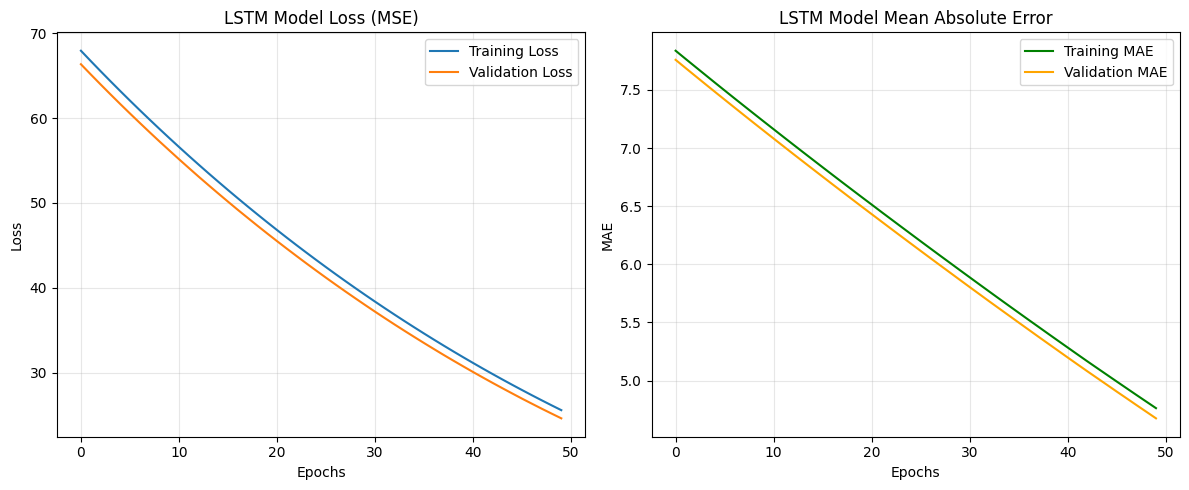

✅ Step 4 Finished: Model is trained and history plot is saved.


In [52]:
#-- Split data for training and testing. --#
X_train, X_val, y_train, y_val = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

#-- Define LSTM Architecture. --#
model_lstm = Sequential([
    # First LSTM layer with Dropout and Batch Normalization for stability
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    
    # Fully connected layers for regression
    Dense(16, activation='relu'),
    Dense(1) # Output layer: Predicted Log-AADT
])

#-- Compile the model. --#
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

#-- Define callbacks for early stopping and learning rate reduction. --#
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

#-- train model. --#
print("🚀 Training LSTM Model...")
history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

#-- Plot and saving. --#
plt.figure(figsize=(12, 5))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plotting MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
plt.title('LSTM Model Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
# Save the training progress plot to Figures folder
plt.savefig('../Figures/lstm_training_history.png', dpi=300)
plt.show()

print("✅ Step 4 Finished: Model is trained and history plot is saved.")

### Model Evaluation ###

In [53]:
#-- Generate predictions and evaluate. --#
y_pred_log = model_lstm.predict(X_val, verbose=0)

#-- Inverse Transform: Convert Log-AADT back to original Traffic Volume. --#
y_val_actual = np.expm1(y_val)
y_pred_actual = np.expm1(y_pred_log).flatten()

#-- Calculate performance matrics. --#
mae = mean_absolute_error(y_val_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
r2 = r2_score(y_val_actual, y_pred_actual)

print(f"--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} vehicles")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} vehicles")
print(f"R-squared Score (R2): {r2:.4f}")


--- Model Performance Metrics ---
Mean Absolute Error (MAE): 9339.44 vehicles
Root Mean Squared Error (RMSE): 15455.79 vehicles
R-squared Score (R2): -0.5744


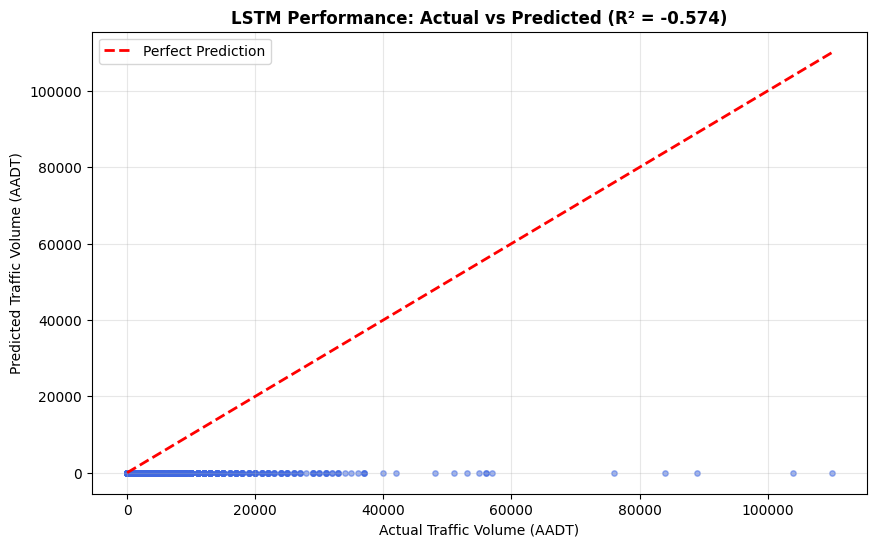

In [54]:
#-- Visualization: Actual vs. Predicted (Scatter Plot). --#
plt.figure(figsize=(10, 6))
plt.scatter(y_val_actual, y_pred_actual, alpha=0.5, color='royalblue', s=15)

#-- Drawing the identity line (Ideal Prediction). --#
max_val = max(y_val_actual.max(), y_pred_actual.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title(f'LSTM Performance: Actual vs Predicted (R² = {r2:.3f})', fontweight='bold')
plt.xlabel('Actual Traffic Volume (AADT)')
plt.ylabel('Predicted Traffic Volume (AADT)')
plt.legend()
plt.grid(True, alpha=0.3)

#-- Save to Figures folder. --#
plt.savefig('../Figures/lstm_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

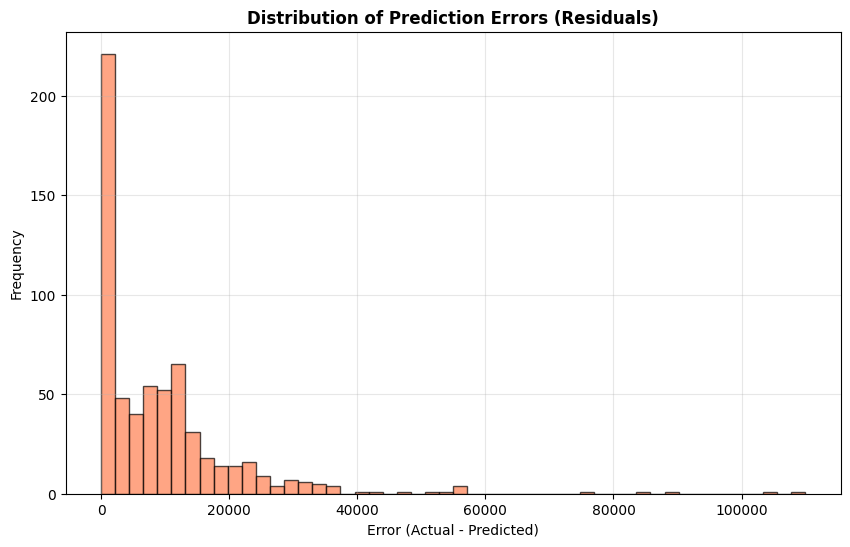

✅ Step 5 Finished: Evaluation reports and plots are saved in 'Figures/'.


In [55]:
#-- Visualization: Prediction Error Distribution. --#
plt.figure(figsize=(10, 6))
errors = y_val_actual - y_pred_actual
plt.hist(errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Prediction Errors (Residuals)', fontweight='bold')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

#-- Save to Figures folder. --#
plt.savefig('../Figures/lstm_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Step 5 Finished: Evaluation reports and plots are saved in 'Figures/'.")

### Step 6: Feature Importance Analysis ###

In [56]:
def calculate_permutation_importance(model, X, y, feature_names):
    baseline_preds = model.predict(X, verbose=0)
    baseline_r2 = r2_score(y, baseline_preds)
    importances = []

    print(f"Calculating importance for {len(feature_names)} features...")
    
    for i in range(X.shape[2]):  # Iterate through each feature index
        X_temp = X.copy()
        #-- Shuffle the values of the specific feature across all sequences and time steps. --#
        save_col = X_temp[:, :, i].copy()
        np.random.shuffle(X_temp[:, :, i])
        
        #-- Measure performance with shuffled feature. --#
        shuffled_preds = model.predict(X_temp, verbose=0)
        shuffled_r2 = r2_score(y, shuffled_preds)
        
        #-- Importance is the drop in R2 score. --#
        drop = baseline_r2 - shuffled_r2
        importances.append(max(0, drop)) # Ensure no negative importance
        
        #-- Restore original values for next iteration. --#
        X_temp[:, :, i] = save_col

    return np.array(importances)

Calculating importance for 31 features...


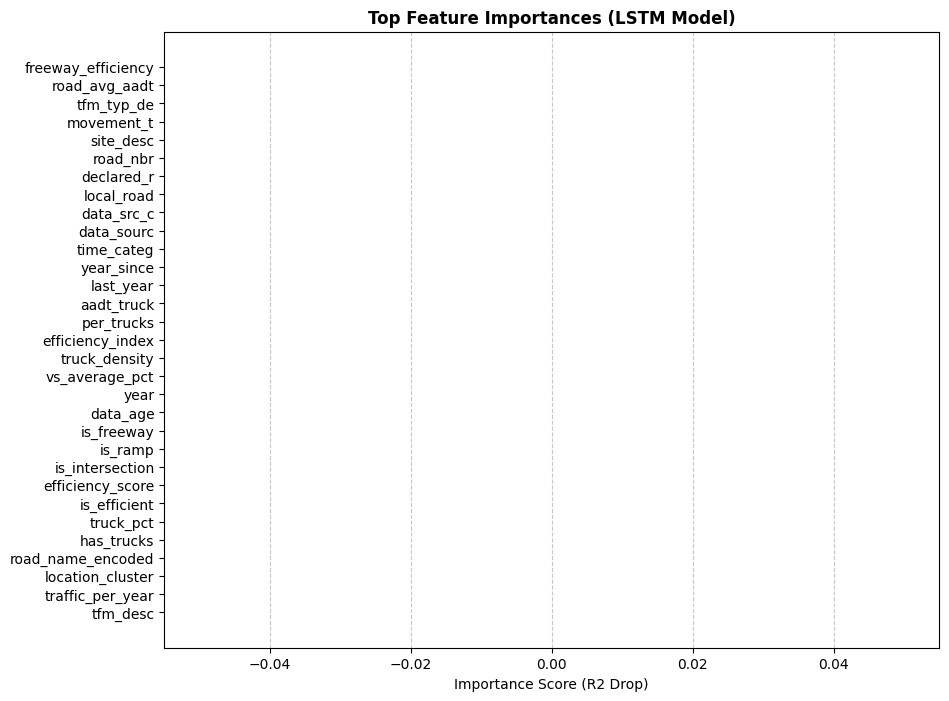

✅ Step 10 Finished: Feature importance analysis is saved in 'Figures/'.


In [57]:
#-- Part 1. Run the importance calculation. --#
feature_importance = calculate_permutation_importance(model_lstm, X_val, y_val, feature_cols)

#-- Part 2. Sort features by importance. --#
sorted_idx = np.argsort(feature_importance)
sorted_features = [feature_cols[i] for i in sorted_idx]
sorted_scores = feature_importance[sorted_idx]

#-- Part 3. Visualization: Horizontal Bar Chart. --#
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), sorted_scores, align='center', color='teal')
plt.yticks(range(len(sorted_idx)), sorted_features)
plt.xlabel('Importance Score (R2 Drop)')
plt.title('Top Feature Importances (LSTM Model)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

#-- Save the plot to your Figures folder. --#
plt.savefig('../Figures/lstm_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Step 10 Finished: Feature importance analysis is saved in 'Figures/'.")

In [63]:
def monitor_lstm_dashboard(model, X_input, df_source):
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    file_timestamp = datetime.now().strftime("%H%M%S")
    
    #-- 1. Real-time Prediction logic. --#
    preds_log = model.predict(X_input, verbose=0)
    preds_actual = np.expm1(preds_log).flatten() # Convert back from Log to Actual AADT
    
    #-- 2. Mapping to original data (Top 10 records for visualization). --#
    results = df_source.iloc[-len(X_input):].copy()
    results = results.head(10) 
    results['Predicted_AADT'] = preds_actual[:10]
    
    #-- 3. Traffic Status & Speed Advisory Logic. --#
    def get_status_advice(row):
        eff = row['efficiency_index']
        limit = 60 # Standard speed limit
        if eff < 0.8:
            return pd.Series(['CONGESTED', f"{limit*0.5:.0f} km/h", 'High Density: Slow Down'])
        elif 0.8 <= eff <= 1.2:
            return pd.Series(['STABLE', f"{limit*0.8:.0f} km/h", 'Normal Flow: Steady'])
        else:
            return pd.Series(['CLEAR', f"{limit:.0f} km/h", 'Low Density: Maintain Limit'])

    results[['Status', 'Target_Speed', 'Guidance']] = results.apply(get_status_advice, axis=1)
    
    #-- 4. Generate Visual Table Dashboard. --#
    display_cols = ['road_name', 'Predicted_AADT', 'Status', 'Target_Speed', 'Guidance']
    plot_df = results[display_cols]

    plt.figure(figsize=(14, 6))
    plt.axis('off')
    
    the_table = plt.table(cellText=plot_df.values, 
                          colLabels=plot_df.columns, 
                          loc='center', 
                          cellLoc='center')
    
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)
    the_table.scale(1.2, 2.2) 
    
    plt.title(f"🚦 LSTM TRAFFIC ADVISORY DASHBOARD\nUpdated at: {now}", 
              fontsize=16, fontweight='bold', pad=30)
    
    #-- Save directly to your existing Figures folder. --#
    save_path = f"../Figures/realtime_dashboard_{file_timestamp}.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.close()
    
    #-- 5. Console Log for tracking. --#
    print(f"\n[SYSTEM UPDATE] Time: {now}")
    print(f"✅ Dashboard generated: {save_path}")

In [ ]:
UPDATE_INTERVAL = 600 

print("🚀 LSTM Real-time System is ACTIVE.")
print("The system will refresh every 10 minutes. Click 'Stop' to terminate.")

try:
    while True:
        # 1. Check if model exists
        # 2. Check if X_val exists (This was the error!)
        if 'model_lstm' in locals() and 'X_val' in locals():
            # Using X_val and df_clean from Step 8 & 9
            monitor_lstm_dashboard(model_lstm, X_val, df_clean)
        else:
            print("❌ Error: Missing 'model_lstm' or 'X_val'.")
            print("Please ensure Step 8 and Step 9 have been executed successfully.")
            break
            
        print(f"\n[WAITING] Next intelligence refresh in {UPDATE_INTERVAL/60} minutes...")
        time.sleep(UPDATE_INTERVAL)
        
except KeyboardInterrupt:
    print("\n[STOPPED] Monitoring system closed by user.")

🚀 LSTM Real-time System is ACTIVE.
The system will refresh every 10 minutes. Click 'Stop' to terminate.


C:\Users\DELL\AppData\Local\Temp\ipykernel_2508\1971942980.py:48: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight', dpi=150)



[SYSTEM UPDATE] Time: 2026-03-31 14:52:37
✅ Dashboard generated: ../Figures/realtime_dashboard_145237.png

[WAITING] Next intelligence refresh in 10.0 minutes...
